In [1]:
# Cell 1: Install and Import Libraries
"""
CBDC Transaction Confirmation Time Analysis
Complete Model Comparison Across All Architectures

Author: Hritik Chaudhary
Kathmandu University - Department of Mathematics

This notebook compares all 5 analytical models:
1. M/M/1 Centralized CBDC
2. M/M/c Permissioned DLT
3. Multi-Stage with Consensus
4. Batch-Based CBDC
5. Priority-Based CBDC
"""

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import factorial
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("="*70)
print("COMPREHENSIVE CBDC MODEL COMPARISON")
print("="*70)
print("\n✓ All libraries imported successfully")

COMPREHENSIVE CBDC MODEL COMPARISON

✓ All libraries imported successfully


In [18]:
# Cell 2: Load All ORIGINAL Model Classes from Individual Notebooks

import simpy

print("\n" + "="*70)
print("LOADING ORIGINAL MODEL CLASSES")
print("="*70)

# ==============================================================================
# MODEL 1: CENTRALIZED CBDC (M/M/1) - FROM mm1 folder
# ==============================================================================

class CentralizedCBDC:
    """M/M/1 Queue - Original from 01_Centralized_MM1.ipynb"""
    
    def __init__(self, env, lam, mu, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu = mu
        self.warm_up = warm_up
        self.server = simpy.Resource(env, capacity=1)
        
        self.data = {
            'txn_id': [],
            'arrival_time': [],
            'service_start': [],
            'departure_time': [],
            'waiting_time': [],
            'service_time': [],
            'system_time': []
        }
        
        self.queue_length_history = []
        self.last_event_time = 0
    
    def update_queue_stats(self):
        current_time = self.env.now
        if current_time > self.last_event_time:
            queue_length = len(self.server.queue)
            self.queue_length_history.append((current_time, queue_length))
            self.last_event_time = current_time
    
    def transaction_generator(self):
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def process_transaction(self, txn_id):
        arrival_time = self.env.now
        
        with self.server.request() as req:
            yield req
            
            self.update_queue_stats()
            
            service_start = self.env.now
            waiting_time = service_start - arrival_time
            
            service_time = np.random.exponential(1.0 / self.mu)
            yield self.env.timeout(service_time)
            
            self.update_queue_stats()
            
            departure_time = self.env.now
            system_time = departure_time - arrival_time
            
            if arrival_time >= self.warm_up:
                self.data['txn_id'].append(txn_id)
                self.data['arrival_time'].append(arrival_time)
                self.data['service_start'].append(service_start)
                self.data['departure_time'].append(departure_time)
                self.data['waiting_time'].append(waiting_time)
                self.data['service_time'].append(service_time)
                self.data['system_time'].append(system_time)
    
    def run(self, duration):
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_queue_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)

print("✓ Model 1: CentralizedCBDC (M/M/1)")

# ==============================================================================
# MODEL 2: PERMISSIONED DLT (M/M/c) - FROM mmc folder
# ==============================================================================

class PermissionedDLT_CBDC:
    """M/M/c Queue - Original from 02_Permissioned_DLT_MMc.ipynb"""
    
    def __init__(self, env, lam, mu, c=5, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu = mu
        self.c = c
        self.warm_up = warm_up
        
        self.validators = simpy.Resource(env, capacity=c)
        
        self.data = {
            'txn_id': [],
            'arrival_time': [],
            'service_start': [],
            'departure_time': [],
            'waiting_time': [],
            'service_time': [],
            'system_time': []
        }
        
        self.queue_length_history = []
        self.system_length_history = []
        self.last_event_time = 0
        self.cumulative_queue_area = 0
        self.cumulative_system_area = 0
    
    def update_stats(self):
        current_time = self.env.now
        if current_time > self.last_event_time:
            time_delta = current_time - self.last_event_time
            
            queue_length = len(self.validators.queue)
            self.cumulative_queue_area += queue_length * time_delta
            self.queue_length_history.append((current_time, queue_length))
            
            system_length = queue_length + self.validators.count
            self.cumulative_system_area += system_length * time_delta
            self.system_length_history.append((current_time, system_length))
            
            self.last_event_time = current_time
    
    def transaction_generator(self):
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def process_transaction(self, txn_id):
        arrival_time = self.env.now
        
        with self.validators.request() as req:
            yield req
            
            self.update_stats()
            
            service_start = self.env.now
            waiting_time = service_start - arrival_time
            
            service_time = np.random.exponential(1.0 / self.mu)
            yield self.env.timeout(service_time)
            
            self.update_stats()
            
            departure_time = self.env.now
            system_time = departure_time - arrival_time
            
            if arrival_time >= self.warm_up:
                self.data['txn_id'].append(txn_id)
                self.data['arrival_time'].append(arrival_time)
                self.data['service_start'].append(service_start)
                self.data['departure_time'].append(departure_time)
                self.data['waiting_time'].append(waiting_time)
                self.data['service_time'].append(service_time)
                self.data['system_time'].append(system_time)
    
    def run(self, duration):
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)

print("✓ Model 2: PermissionedDLT_CBDC (M/M/c)")

# ==============================================================================
# MODEL 3: MULTI-STAGE - FROM multistage folder
# ==============================================================================

class MultistageCBDC:
    """Multi-Stage with Consensus - Original from 03_Multistage_CBDC_with_Consensus.ipynb"""
    
    def __init__(self, env, lam, mu_v, mu_c, mu_l, c=5, q=3, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu_v = mu_v
        self.mu_c = mu_c
        self.mu_l = mu_l
        self.c = c
        self.q = q
        self.warm_up = warm_up
        
        if q <= c/2:
            raise ValueError(f"Quorum q={q} must be > c/2 = {c/2}")
        if q > c:
            raise ValueError(f"Quorum q={q} cannot exceed validator count c={c}")
        
        self.validators = simpy.Resource(env, capacity=c)
        
        self.data = {
            'txn_id': [],
            'arrival_time': [],
            'validation_start': [],
            'validation_end': [],
            'consensus_start': [],
            'consensus_end': [],
            'commit_start': [],
            'commit_end': [],
            'departure_time': [],
            'queueing_time': [],
            'validation_time': [],
            'consensus_time': [],
            'commit_time': [],
            'total_time': []
        }
        
        self.queue_length_history = []
        self.last_event_time = 0
    
    def update_queue_stats(self):
        current_time = self.env.now
        if current_time > self.last_event_time:
            queue_length = len(self.validators.queue)
            time_delta = current_time - self.last_event_time
            
            self.queue_length_history.append((current_time, queue_length))
            self.last_event_time = current_time
    
    def transaction_generator(self):
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def simulate_consensus_delay(self):
        response_times = np.random.exponential(1.0 / self.mu_c, size=self.c)
        sorted_times = np.sort(response_times)
        return sorted_times[self.q - 1]
    
    def process_transaction(self, txn_id):
        arrival_time = self.env.now
        
        # STAGE 1: Queueing + Validation
        with self.validators.request() as req:
            yield req
            
            self.update_queue_stats()
            
            validation_start = self.env.now
            queueing_time = validation_start - arrival_time
            
            validation_time = np.random.exponential(1.0 / self.mu_v)
            yield self.env.timeout(validation_time)
            
            validation_end = self.env.now
        
        # STAGE 2: Consensus
        consensus_start = self.env.now
        consensus_time = self.simulate_consensus_delay()
        yield self.env.timeout(consensus_time)
        
        consensus_end = self.env.now
        
        # STAGE 3: Ledger Commitment
        commit_start = self.env.now
        commit_time = np.random.exponential(1.0 / self.mu_l)
        yield self.env.timeout(commit_time)
        
        commit_end = self.env.now
        departure_time = commit_end
        
        total_time = departure_time - arrival_time
        
        if arrival_time >= self.warm_up:
            self.data['txn_id'].append(txn_id)
            self.data['arrival_time'].append(arrival_time)
            self.data['validation_start'].append(validation_start)
            self.data['validation_end'].append(validation_end)
            self.data['consensus_start'].append(consensus_start)
            self.data['consensus_end'].append(consensus_end)
            self.data['commit_start'].append(commit_start)
            self.data['commit_end'].append(commit_end)
            self.data['departure_time'].append(departure_time)
            self.data['queueing_time'].append(queueing_time)
            self.data['validation_time'].append(validation_time)
            self.data['consensus_time'].append(consensus_time)
            self.data['commit_time'].append(commit_time)
            self.data['total_time'].append(total_time)
    
    def run(self, duration):
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_queue_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)

print("✓ Model 3: MultistageCBDC")

# ==============================================================================
# MODEL 4: BATCH-BASED - FROM batch_queue folder
# ==============================================================================

class BatchBasedCBDC:
    """Batch-Based CBDC - Original from 04_Batch_Based_CBDC.ipynb"""
    
    def __init__(self, env, lam, mu_v, mu_c, mu_l, c=5, q=3, batch_mode='size', B=50, tau=2.0, warm_up=300):
        self.env = env
        self.lam = lam
        self.mu_v = mu_v
        self.mu_c = mu_c
        self.mu_l = mu_l
        self.c = c
        self.q = q
        self.batch_mode = batch_mode
        self.B = B
        self.tau = tau
        self.warm_up = warm_up
        
        if q <= c/2:
            raise ValueError(f"Quorum q={q} must be > c/2 = {c/2}")
        if batch_mode not in ['size', 'time']:
            raise ValueError(f"batch_mode must be 'size' or 'time', got '{batch_mode}'")
        
        self.validators = simpy.Resource(env, capacity=c)
        
        self.current_batch = []
        self.batch_counter = 0
        
        self.data = {
            'txn_id': [],
            'batch_id': [],
            'arrival_time': [],
            'batch_entry_time': [],
            'batch_close_time': [],
            'departure_time': [],
            'queueing_time': [],
            'individual_validation_time': [],
            'batch_formation_time': [],
            'batch_validation_time': [],
            'consensus_time': [],
            'commit_time': [],
            'total_time': []
        }
        
        self.queue_length_history = []
        self.last_event_time = 0
        
        self.env.process(self.batch_processor())
    
    def update_queue_stats(self):
        current_time = self.env.now
        if current_time > self.last_event_time:
            queue_length = len(self.validators.queue)
            self.queue_length_history.append((current_time, queue_length))
            self.last_event_time = current_time
    
    def transaction_generator(self):
        txn_id = 0
        while True:
            inter_arrival = np.random.exponential(1.0 / self.lam)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id))
    
    def simulate_consensus_delay(self):
        response_times = np.random.exponential(1.0 / self.mu_c, size=self.c)
        sorted_times = np.sort(response_times)
        return sorted_times[self.q - 1]
    
    def process_transaction(self, txn_id):
        arrival_time = self.env.now
        
        with self.validators.request() as req:
            yield req
            
            self.update_queue_stats()
            
            validation_start = self.env.now
            queueing_time = validation_start - arrival_time
            
            individual_validation_time = np.random.exponential(1.0 / self.mu_v)
            yield self.env.timeout(individual_validation_time)
            
            validation_end = self.env.now
        
        batch_entry_time = self.env.now
        
        transaction_data = {
            'txn_id': txn_id,
            'arrival_time': arrival_time,
            'batch_entry_time': batch_entry_time,
            'queueing_time': queueing_time,
            'individual_validation_time': individual_validation_time
        }
        
        self.current_batch.append(transaction_data)
    
    def batch_processor(self):
        next_close_time = self.env.now + self.tau if self.batch_mode == 'time' else None
        
        while True:
            if self.batch_mode == 'size':
                while len(self.current_batch) < self.B:
                    yield self.env.timeout(0.1)
            else:
                wait_time = next_close_time - self.env.now
                if wait_time > 0:
                    yield self.env.timeout(wait_time)
                next_close_time = self.env.now + self.tau
            
            if len(self.current_batch) > 0:
                batch = self.current_batch.copy()
                self.current_batch = []
                self.batch_counter += 1
                
                batch_close_time = self.env.now
                batch_id = self.batch_counter
                
                yield self.env.process(self.process_batch(batch, batch_id, batch_close_time))
    
    def process_batch(self, batch, batch_id, batch_close_time):
        batch_validation_start = self.env.now
        batch_validation_time = np.random.exponential(1.0 / self.mu_v)
        yield self.env.timeout(batch_validation_time)
        batch_validation_end = self.env.now
        
        consensus_start = self.env.now
        consensus_time = self.simulate_consensus_delay()
        yield self.env.timeout(consensus_time)
        consensus_end = self.env.now
        
        commit_start = self.env.now
        commit_time = np.random.exponential(1.0 / self.mu_l)
        yield self.env.timeout(commit_time)
        commit_end = self.env.now
        
        departure_time = commit_end
        
        for txn in batch:
            if txn['arrival_time'] >= self.warm_up:
                batch_formation_time = batch_close_time - txn['batch_entry_time']
                total_time = departure_time - txn['arrival_time']
                
                self.data['txn_id'].append(txn['txn_id'])
                self.data['batch_id'].append(batch_id)
                self.data['arrival_time'].append(txn['arrival_time'])
                self.data['batch_entry_time'].append(txn['batch_entry_time'])
                self.data['batch_close_time'].append(batch_close_time)
                self.data['departure_time'].append(departure_time)
                self.data['queueing_time'].append(txn['queueing_time'])
                self.data['individual_validation_time'].append(txn['individual_validation_time'])
                self.data['batch_formation_time'].append(batch_formation_time)
                self.data['batch_validation_time'].append(batch_validation_time)
                self.data['consensus_time'].append(consensus_time)
                self.data['commit_time'].append(commit_time)
                self.data['total_time'].append(total_time)
    
    def run(self, duration):
        self.env.process(self.transaction_generator())
        self.env.run(until=duration)
        self.update_queue_stats()
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)

print("✓ Model 4: BatchBasedCBDC")

# ==============================================================================
# MODEL 5: PRIORITY-BASED - FROM priority folder
# ==============================================================================

class PriorityBasedCBDC:
    """Priority Queue - Original from 05_Priority_Based_CBDC.ipynb"""
    
    def __init__(self, env, lambda_rates, mu, K=3, warm_up=300):
        self.env = env
        self.lambda_rates = lambda_rates
        self.mu = mu
        self.K = K
        self.warm_up = warm_up
        
        if len(lambda_rates) != K:
            raise ValueError(f"lambda_rates must have {K} elements, got {len(lambda_rates)}")
        
        total_lambda = sum(lambda_rates)
        self.total_rho = total_lambda / mu
        
        if self.total_rho >= 1:
            raise ValueError(f"System unstable: ρ = {self.total_rho:.4f} >= 1")
        
        self.server = simpy.PriorityResource(env, capacity=1)
        
        self.data = {
            'txn_id': [],
            'priority_class': [],
            'arrival_time': [],
            'service_start': [],
            'departure_time': [],
            'waiting_time': [],
            'service_time': [],
            'system_time': []
        }
        
        self.class_stats = {k: {'count': 0, 'total_wait': 0} for k in range(1, K+1)}
        
        self.queue_length_history = []
        self.last_event_time = 0
        
        for priority_class in range(1, K+1):
            self.env.process(self.transaction_generator(priority_class))
    
    def update_queue_stats(self):
        current_time = self.env.now
        if current_time > self.last_event_time:
            total_queue = len(self.server.put_queue)
            self.queue_length_history.append((current_time, total_queue))
            self.last_event_time = current_time
    
    def transaction_generator(self, priority_class):
        txn_id = 0
        lambda_k = self.lambda_rates[priority_class - 1]
        
        while True:
            inter_arrival = np.random.exponential(1.0 / lambda_k)
            yield self.env.timeout(inter_arrival)
            
            self.update_queue_stats()
            
            txn_id += 1
            self.env.process(self.process_transaction(txn_id, priority_class))
    
    def process_transaction(self, txn_id, priority_class):
        arrival_time = self.env.now
        
        with self.server.request(priority=priority_class) as req:
            yield req
            
            self.update_queue_stats()
            
            service_start = self.env.now
            waiting_time = service_start - arrival_time
            
            service_time = np.random.exponential(1.0 / self.mu)
            yield self.env.timeout(service_time)
            
            self.update_queue_stats()
            
            departure_time = self.env.now
            system_time = departure_time - arrival_time
            
            if arrival_time >= self.warm_up:
                self.data['txn_id'].append(txn_id)
                self.data['priority_class'].append(priority_class)
                self.data['arrival_time'].append(arrival_time)
                self.data['service_start'].append(service_start)
                self.data['departure_time'].append(departure_time)
                self.data['waiting_time'].append(waiting_time)
                self.data['service_time'].append(service_time)
                self.data['system_time'].append(system_time)
                
                self.class_stats[priority_class]['count'] += 1
                self.class_stats[priority_class]['total_wait'] += waiting_time
    
    def run(self, duration):
        self.env.run(until=duration)
    
    def get_dataframe(self):
        return pd.DataFrame(self.data)

print("✓ Model 5: PriorityBasedCBDC")

print("\n" + "="*70)
print("✓ ALL 5 ORIGINAL MODEL CLASSES LOADED SUCCESSFULLY")
print("="*70)


LOADING ORIGINAL MODEL CLASSES
✓ Model 1: CentralizedCBDC (M/M/1)
✓ Model 2: PermissionedDLT_CBDC (M/M/c)
✓ Model 3: MultistageCBDC
✓ Model 4: BatchBasedCBDC
✓ Model 5: PriorityBasedCBDC

✓ ALL 5 ORIGINAL MODEL CLASSES LOADED SUCCESSFULLY


In [19]:
# Cell 3: Define Common Parameters for Fair Comparison

print("\n" + "="*70)
print("COMMON SIMULATION PARAMETERS")
print("="*70)

# Common parameters
LAM = 200          # Arrival rate: 200 TPS
MU = 150           # Service rate: 150 TPS per server
C = 5              # Number of validators
Q = 3              # Quorum threshold
WARM_UP = 300      # 5 minutes warm-up
DURATION = 3600    # 1 hour simulation

# Model-specific parameters
MU_V = 150         # Validation rate (multi-stage, batch)
MU_C = 200         # Consensus rate (multi-stage, batch)
MU_L = 300         # Ledger rate (multi-stage, batch)
B = 50             # Batch size (batch-based)

# Priority parameters
LAMBDA_PRIORITY = [10, 40, 150]  # Critical, High, Normal
MU_PRIORITY = 250  # Higher service rate for priority model

print(f"\nCommon Parameters:")
print(f"  Arrival Rate (λ):        {LAM} TPS")
print(f"  Service Rate (μ):        {MU} TPS")
print(f"  Validators (c):          {C}")
print(f"  Quorum (q):              {Q}")
print(f"  Warm-up:                 {WARM_UP} seconds")
print(f"  Duration:                {DURATION} seconds")
print(f"  Batch Size (B):          {B} transactions")
print(f"  Priority Mix:            {LAMBDA_PRIORITY} TPS")
print(f"\n  Total Utilization:")
print(f"    M/M/1:                 ρ = {LAM/MU:.4f}")
print(f"    M/M/c:                 ρ = {LAM/(C*MU):.4f}")
print(f"    Priority:              ρ = {sum(LAMBDA_PRIORITY)/MU_PRIORITY:.4f}")


COMMON SIMULATION PARAMETERS

Common Parameters:
  Arrival Rate (λ):        200 TPS
  Service Rate (μ):        150 TPS
  Validators (c):          5
  Quorum (q):              3
  Warm-up:                 300 seconds
  Duration:                3600 seconds
  Batch Size (B):          50 transactions
  Priority Mix:            [10, 40, 150] TPS

  Total Utilization:
    M/M/1:                 ρ = 1.3333
    M/M/c:                 ρ = 0.2667
    Priority:              ρ = 0.8000


In [21]:
# Cell 4: Run All Models - Flag Unstable Models for Nepal's 200 TPS Load

np.random.seed(42)  # For reproducibility

results = {}
unstable_models = []

print("\n" + "="*70)
print("RUNNING ALL MODELS AT NEPAL'S PROJECTED LOAD (200 TPS)")
print("="*70)

# Model 1: Centralized (M/M/1) - Check Stability First
print("\n[1/5] Checking Model 1: Centralized CBDC (M/M/1)...")
rho_mm1 = LAM / MU
print(f"  Utilization: ρ = λ/μ = {LAM}/{MU} = {rho_mm1:.4f}")

if rho_mm1 >= 1.0:
    print(f"  ❌ UNSTABLE: ρ ≥ 1.0 - Model cannot handle {LAM} TPS")
    print(f"  Maximum capacity: {MU} TPS")
    print(f"  Recommendation: NOT SUITABLE for Nepal's 200 TPS requirement")
    print(f"  STATUS: Excluded from comparison graphs")
    unstable_models.append('Centralized (M/M/1)')
    results['Centralized (M/M/1)'] = None  # Mark as unstable
else:
    print(f"  ✅ STABLE: Running simulation...")
    env1 = simpy.Environment()
    model1 = CentralizedCBDC(env1, lam=LAM, mu=MU, warm_up=WARM_UP)
    model1.run(DURATION)
    df1 = model1.get_dataframe()
    results['Centralized (M/M/1)'] = df1
    print(f"  ✓ Completed: {len(df1):,} transactions")
    print(f"  Mean time: {df1['system_time'].mean() * 1000:.2f} ms")

# Model 2: Permissioned DLT (M/M/c)
print("\n[2/5] Running Model 2: Permissioned DLT (M/M/c)...")
rho_mmc = LAM / (C * MU)
print(f"  Utilization: ρ = λ/(c×μ) = {LAM}/({C}×{MU}) = {rho_mmc:.4f}")
if rho_mmc >= 1.0:
    print(f"  ❌ UNSTABLE")
    unstable_models.append('Permissioned DLT (M/M/c)')
    results['Permissioned DLT (M/M/c)'] = None
else:
    print(f"  ✅ STABLE: Running simulation...")
    env2 = simpy.Environment()
    model2 = PermissionedDLT_CBDC(env2, lam=LAM, mu=MU, c=C, warm_up=WARM_UP)
    model2.run(DURATION)
    df2 = model2.get_dataframe()
    results['Permissioned DLT (M/M/c)'] = df2
    print(f"  ✓ Completed: {len(df2):,} transactions")
    print(f"  Mean time: {df2['system_time'].mean() * 1000:.2f} ms")
    print(f"  P95 time:  {df2['system_time'].quantile(0.95) * 1000:.2f} ms")

# Model 3: Multi-Stage
print("\n[3/5] Running Model 3: Multi-Stage with Consensus...")
rho_multi = LAM / (C * MU_V)
print(f"  Utilization: ρ = λ/(c×μ_v) = {LAM}/({C}×{MU_V}) = {rho_multi:.4f}")
if rho_multi >= 1.0:
    print(f"  ❌ UNSTABLE")
    unstable_models.append('Multi-Stage')
    results['Multi-Stage'] = None
else:
    print(f"  ✅ STABLE: Running simulation...")
    env3 = simpy.Environment()
    model3 = MultistageCBDC(env3, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, c=C, q=Q, warm_up=WARM_UP)
    model3.run(DURATION)
    df3 = model3.get_dataframe()
    results['Multi-Stage'] = df3
    print(f"  ✓ Completed: {len(df3):,} transactions")
    print(f"  Mean time: {df3['total_time'].mean() * 1000:.2f} ms")
    print(f"  P95 time:  {df3['total_time'].quantile(0.95) * 1000:.2f} ms")

# Model 4: Batch-Based
print("\n[4/5] Running Model 4: Batch-Based CBDC...")
rho_batch = LAM / (C * MU_V)
print(f"  Utilization: ρ = λ/(c×μ_v) = {LAM}/({C}×{MU_V}) = {rho_batch:.4f}")
if rho_batch >= 1.0:
    print(f"  ❌ UNSTABLE")
    unstable_models.append('Batch-Based')
    results['Batch-Based'] = None
else:
    print(f"  ✅ STABLE: Running simulation...")
    env4 = simpy.Environment()
    model4 = BatchBasedCBDC(env4, lam=LAM, mu_v=MU_V, mu_c=MU_C, mu_l=MU_L, 
                             c=C, q=Q, batch_mode='size', B=B, tau=2.0, warm_up=WARM_UP)
    model4.run(DURATION)
    df4 = model4.get_dataframe()
    results['Batch-Based'] = df4
    print(f"  ✓ Completed: {len(df4):,} transactions")
    print(f"  Mean time: {df4['total_time'].mean() * 1000:.2f} ms")
    print(f"  P95 time:  {df4['total_time'].quantile(0.95) * 1000:.2f} ms")

# Model 5: Priority-Based
print("\n[5/5] Running Model 5: Priority-Based CBDC...")
rho_priority = sum(LAMBDA_PRIORITY) / MU_PRIORITY
print(f"  Utilization: ρ = Σλₖ/μ = {sum(LAMBDA_PRIORITY)}/{MU_PRIORITY} = {rho_priority:.4f}")
if rho_priority >= 1.0:
    print(f"  ❌ UNSTABLE")
    unstable_models.append('Priority-Based')
    results['Priority-Based'] = None
else:
    print(f"  ✅ STABLE: Running simulation...")
    env5 = simpy.Environment()
    model5 = PriorityBasedCBDC(env5, lambda_rates=LAMBDA_PRIORITY, mu=MU_PRIORITY, K=3, warm_up=WARM_UP)
    model5.run(DURATION)
    df5 = model5.get_dataframe()
    results['Priority-Based'] = df5
    print(f"  ✓ Completed: {len(df5):,} transactions")
    print(f"  Mean time: {df5['system_time'].mean() * 1000:.2f} ms")
    print(f"  P95 time:  {df5['system_time'].quantile(0.95) * 1000:.2f} ms")

print("\n" + "="*70)
print("SIMULATION SUMMARY")
print("="*70)

stable_count = sum(1 for v in results.values() if v is not None)
print(f"\n  Stable Models:   {stable_count}/5")
print(f"  Unstable Models: {len(unstable_models)}/5")

if unstable_models:
    print(f"\n  ⚠️  Models Excluded from Comparison (Unstable at 200 TPS):")
    for model in unstable_models:
        print(f"      • {model}")
    print(f"\n  These models cannot handle Nepal's projected 200 TPS load.")
    print(f"  They are excluded from comparison graphs but documented in analysis.")

print("\n" + "="*70)
print("✓ SIMULATION COMPLETE")
print("="*70)


RUNNING ALL MODELS AT NEPAL'S PROJECTED LOAD (200 TPS)

[1/5] Checking Model 1: Centralized CBDC (M/M/1)...
  Utilization: ρ = λ/μ = 200/150 = 1.3333
  ❌ UNSTABLE: ρ ≥ 1.0 - Model cannot handle 200 TPS
  Maximum capacity: 150 TPS
  Recommendation: NOT SUITABLE for Nepal's 200 TPS requirement
  STATUS: Excluded from comparison graphs

[2/5] Running Model 2: Permissioned DLT (M/M/c)...
  Utilization: ρ = λ/(c×μ) = 200/(5×150) = 0.2667
  ✅ STABLE: Running simulation...
  ✓ Completed: 659,275 transactions
  Mean time: 6.69 ms
  P95 time:  20.05 ms

[3/5] Running Model 3: Multi-Stage with Consensus...
  Utilization: ρ = λ/(c×μ_v) = 200/(5×150) = 0.2667
  ✅ STABLE: Running simulation...
  ✓ Completed: 660,576 transactions
  Mean time: 13.95 ms
  P95 time:  28.98 ms

[4/5] Running Model 4: Batch-Based CBDC...
  Utilization: ρ = λ/(c×μ_v) = 200/(5×150) = 0.2667
  ✅ STABLE: Running simulation...
  ✓ Completed: 658,655 transactions
  Mean time: 171.48 ms
  P95 time:  319.55 ms

[5/5] Running Mo

In [22]:
# Cell 5: Calculate Comparison Metrics - Stable Models Only

print("\n" + "="*70)
print("CALCULATING COMPARISON METRICS (STABLE MODELS ONLY)")
print("="*70)

comparison_data = []

for model_name, df in results.items():
    # Skip unstable models
    if df is None:
        continue
    
    # Handle different column names
    if 'system_time' in df.columns:
        time_col = 'system_time'
    elif 'total_time' in df.columns:
        time_col = 'total_time'
    else:
        print(f"Warning: No time column found for {model_name}")
        continue
    
    metrics = {
        'Model': model_name,
        'Transactions': len(df),
        'Mean Time (ms)': df[time_col].mean() * 1000,
        'Median Time (ms)': df[time_col].median() * 1000,
        'Std Dev (ms)': df[time_col].std() * 1000,
        'P95 Time (ms)': df[time_col].quantile(0.95) * 1000,
        'P99 Time (ms)': df[time_col].quantile(0.99) * 1000,
        'Min Time (ms)': df[time_col].min() * 1000,
        'Max Time (ms)': df[time_col].max() * 1000,
        'Throughput (TPS)': len(df) / (DURATION - WARM_UP)
    }
    
    comparison_data.append(metrics)

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print(f"PERFORMANCE COMPARISON - VIABLE MODELS FOR NEPAL (200 TPS)")
print("="*70)
print("\n", comparison_df.to_string(index=False))

# Find best model
if len(comparison_df) > 0:
    best_mean = comparison_df.loc[comparison_df['Mean Time (ms)'].idxmin(), 'Model']
    best_p95 = comparison_df.loc[comparison_df['P95 Time (ms)'].idxmin(), 'Model']
    
    print("\n" + "="*70)
    print("WINNERS (Among Viable Models):")
    print("="*70)
    print(f"  Best Mean Confirmation Time:  {best_mean}")
    print(f"  Best P95 Confirmation Time:   {best_p95}")
    
    if unstable_models:
        print(f"\n  Note: {len(unstable_models)} model(s) excluded due to instability:")
        for model in unstable_models:
            print(f"        • {model}")


CALCULATING COMPARISON METRICS (STABLE MODELS ONLY)

PERFORMANCE COMPARISON - VIABLE MODELS FOR NEPAL (200 TPS)

                    Model  Transactions  Mean Time (ms)  Median Time (ms)  Std Dev (ms)  P95 Time (ms)  P99 Time (ms)  Min Time (ms)  Max Time (ms)  Throughput (TPS)
Permissioned DLT (M/M/c)        659275        6.689457          4.646844      6.675761      20.051980      30.693319       0.000003      88.624417        199.780303
             Multi-Stage        660576       13.951234         12.298298      7.818402      28.978204      39.773539       0.393264     122.272555        200.174545
             Batch-Based        658655      171.476350        167.531330     91.992581     319.550925     356.313525       2.617913     488.263674        199.592424
          Priority-Based        660199       19.964558         11.365341     23.573013      68.689119     110.801514       0.000002     280.764644        200.060303

WINNERS (Among Viable Models):
  Best Mean Confirmation Tim

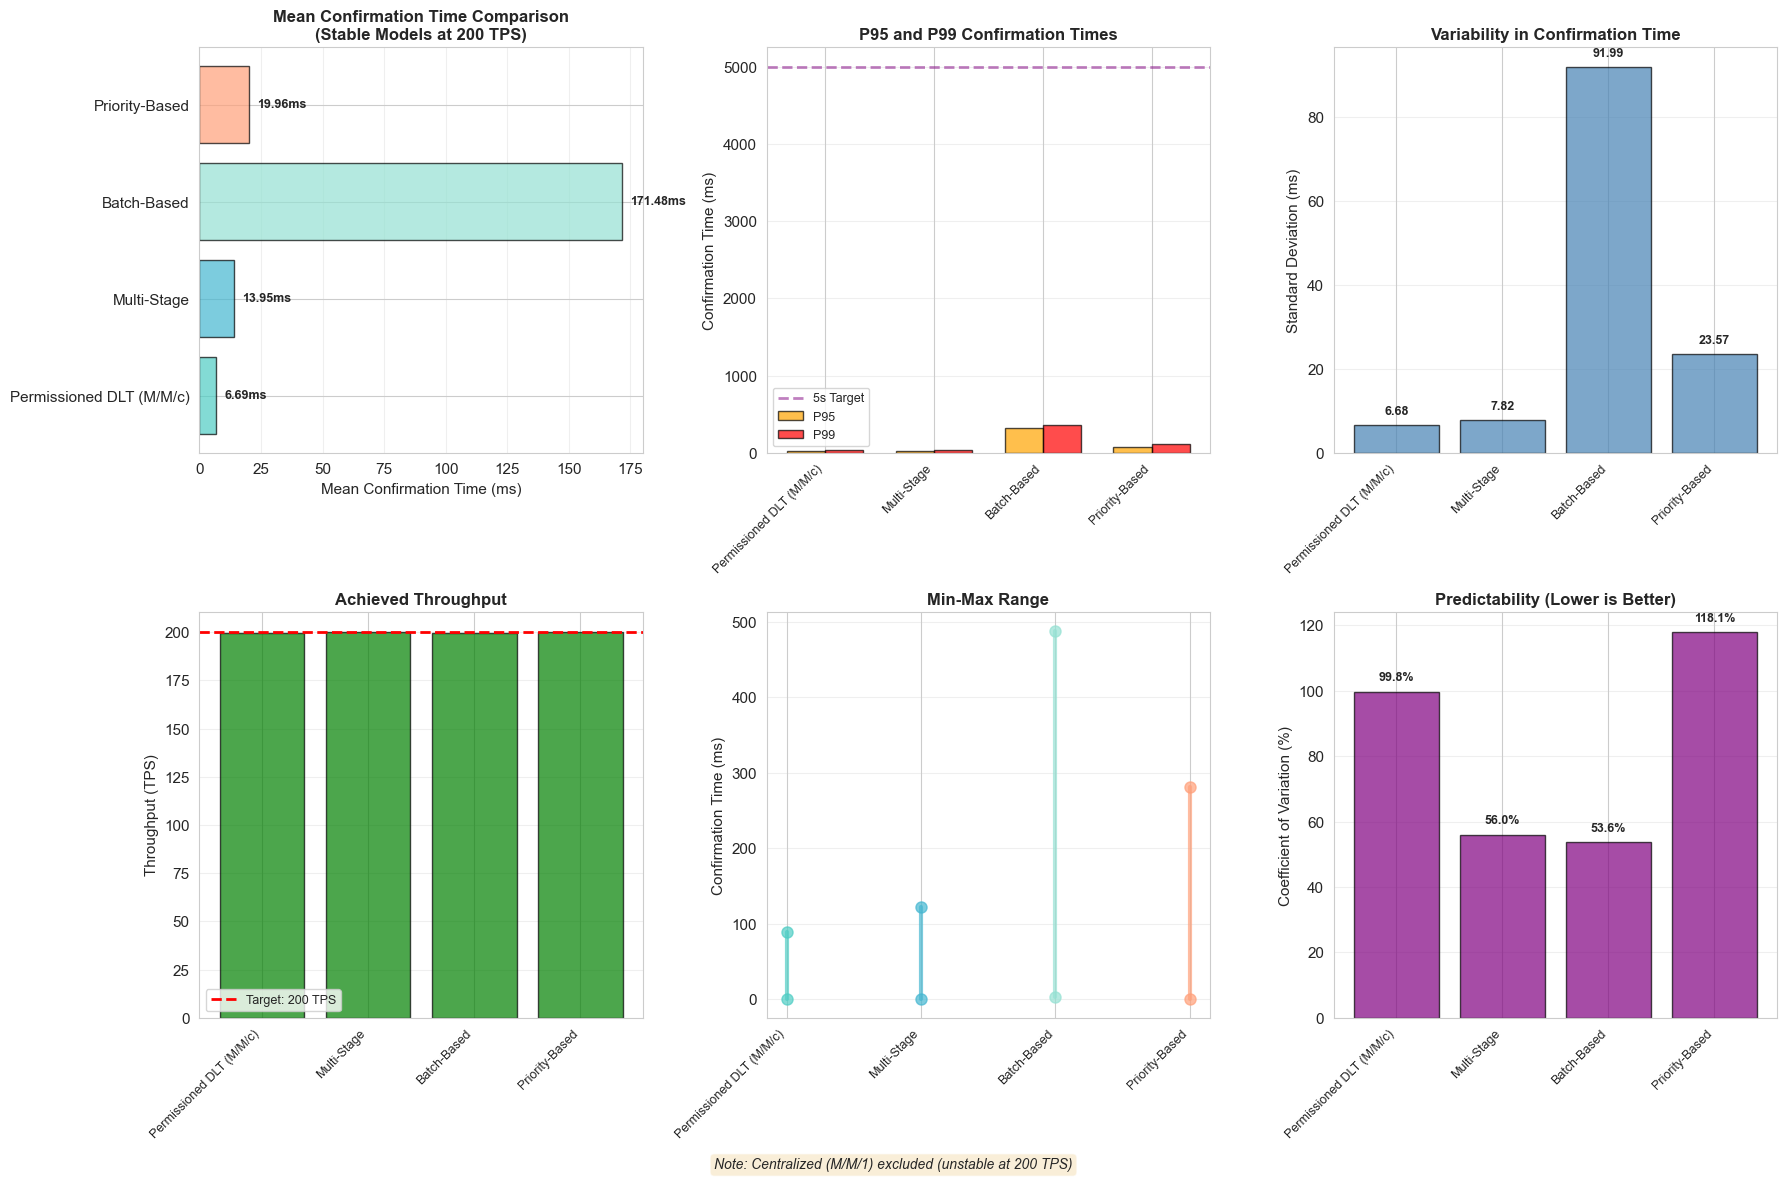

✓ Comparison metrics visualization saved (stable models only)


In [24]:
# Cell 6: Comprehensive Comparison Visualization - Stable Models Only

# Filter out unstable models
stable_results = {k: v for k, v in results.items() if v is not None}

if len(stable_results) == 0:
    print("ERROR: No stable models to compare!")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Mean Confirmation Time Comparison
    model_names = comparison_df['Model']
    mean_times = comparison_df['Mean Time (ms)']
    
    colors = ['#4ECDC4', '#45B7D1', '#95E1D3', '#FFA07A'][:len(model_names)]
    
    bars1 = axes[0, 0].barh(model_names, mean_times, color=colors, 
                             edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Mean Confirmation Time (ms)', fontsize=11)
    axes[0, 0].set_title('Mean Confirmation Time Comparison\n(Stable Models at 200 TPS)', 
                         fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3, axis='x')
    
    # Add values on bars
    for i, (bar, val) in enumerate(zip(bars1, mean_times)):
        axes[0, 0].text(val + max(mean_times)*0.02, i, f'{val:.2f}ms', 
                        va='center', fontsize=9, fontweight='bold')
    
    # 2. P95 and P99 Comparison
    x = np.arange(len(model_names))
    width = 0.35
    
    p95_times = comparison_df['P95 Time (ms)']
    p99_times = comparison_df['P99 Time (ms)']
    
    axes[0, 1].bar(x - width/2, p95_times, width, label='P95', 
                   color='orange', alpha=0.7, edgecolor='black')
    axes[0, 1].bar(x + width/2, p99_times, width, label='P99', 
                   color='red', alpha=0.7, edgecolor='black')
    axes[0, 1].axhline(5000, color='purple', linestyle='--', linewidth=2, alpha=0.5, 
                       label='5s Target')
    axes[0, 1].set_ylabel('Confirmation Time (ms)', fontsize=11)
    axes[0, 1].set_title('P95 and P99 Confirmation Times', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(alpha=0.3, axis='y')
    
    # 3. Standard Deviation Comparison
    std_devs = comparison_df['Std Dev (ms)']
    
    bars3 = axes[0, 2].bar(model_names, std_devs, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, 2].set_ylabel('Standard Deviation (ms)', fontsize=11)
    axes[0, 2].set_title('Variability in Confirmation Time', fontsize=12, fontweight='bold')
    axes[0, 2].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    axes[0, 2].grid(alpha=0.3, axis='y')
    
    for bar, val in zip(bars3, std_devs):
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + max(std_devs)*0.02,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. Throughput Comparison
    throughputs = comparison_df['Throughput (TPS)']
    
    bars4 = axes[1, 0].bar(model_names, throughputs, color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].axhline(LAM, color='red', linestyle='--', linewidth=2, 
                       label=f'Target: {LAM} TPS')
    axes[1, 0].set_ylabel('Throughput (TPS)', fontsize=11)
    axes[1, 0].set_title('Achieved Throughput', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(alpha=0.3, axis='y')
    
    # 5. Min vs Max Time Range
    min_times = comparison_df['Min Time (ms)']
    max_times = comparison_df['Max Time (ms)']
    
    for i, model in enumerate(model_names):
        axes[1, 1].plot([i, i], [min_times.iloc[i], max_times.iloc[i]], 
                        'o-', linewidth=3, markersize=8, alpha=0.7, 
                        color=colors[i])
    
    axes[1, 1].set_ylabel('Confirmation Time (ms)', fontsize=11)
    axes[1, 1].set_title('Min-Max Range', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(range(len(model_names)))
    axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    axes[1, 1].grid(alpha=0.3, axis='y')
    
    # 6. Coefficient of Variation (CV)
    cv = (comparison_df['Std Dev (ms)'] / comparison_df['Mean Time (ms)']) * 100
    
    bars6 = axes[1, 2].bar(model_names, cv, color='purple', alpha=0.7, edgecolor='black')
    axes[1, 2].set_ylabel('Coefficient of Variation (%)', fontsize=11)
    axes[1, 2].set_title('Predictability (Lower is Better)', fontsize=12, fontweight='bold')
    axes[1, 2].set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    axes[1, 2].grid(alpha=0.3, axis='y')
    
    for bar, val in zip(bars6, cv):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + max(cv)*0.02,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add note about excluded models
    if unstable_models:
        fig.text(0.5, 0.02, 
                 f'Note: {", ".join(unstable_models)} excluded (unstable at 200 TPS)',
                 ha='center', fontsize=10, style='italic', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig('model_comparison_metrics_stable_only.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Comparison metrics visualization saved (stable models only)")

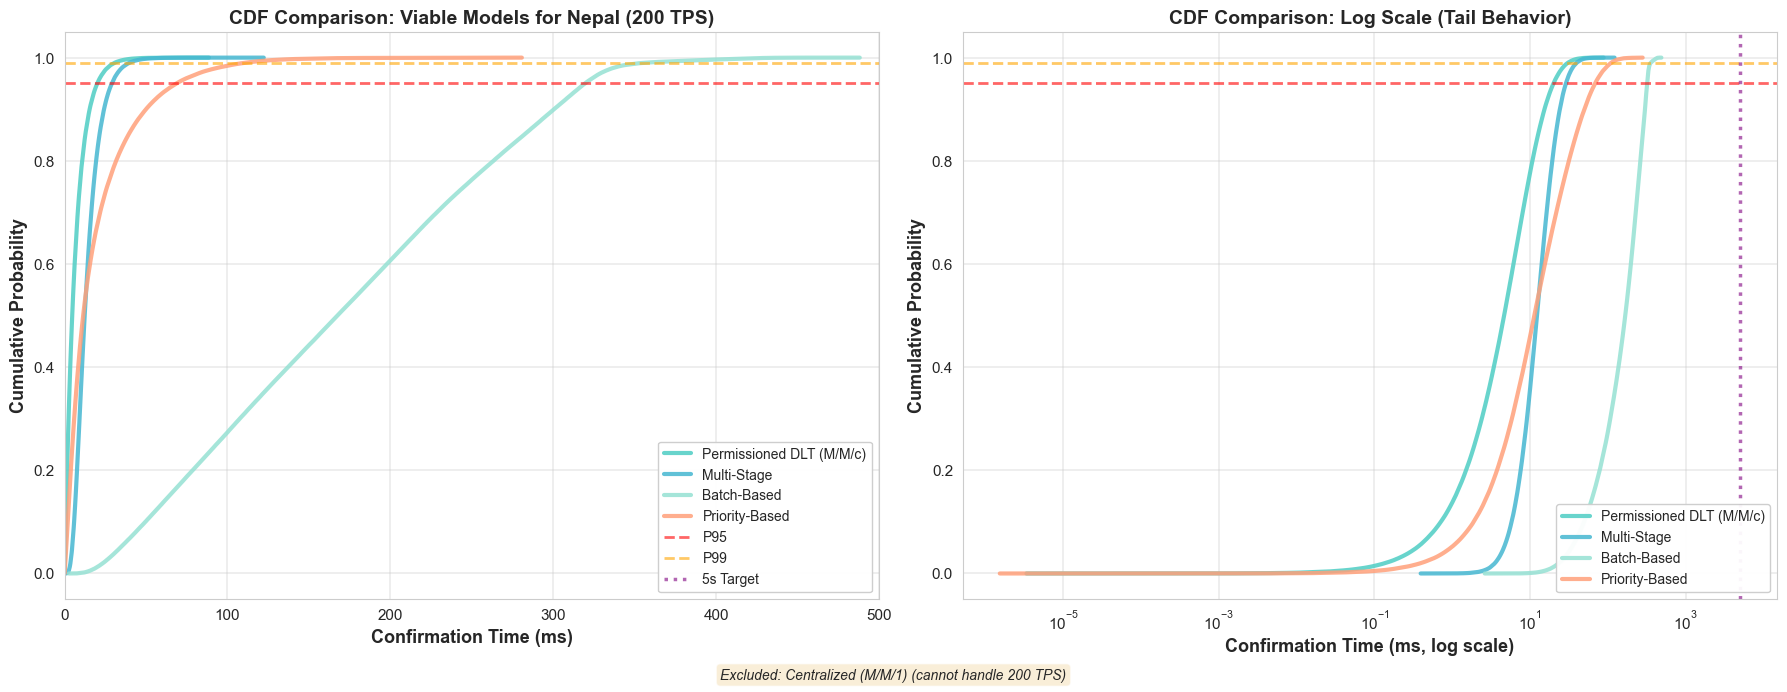

✓ CDF comparison saved (stable models only)


In [25]:
# Cell 7: CDF Comparison - Stable Models Only

stable_results = {k: v for k, v in results.items() if v is not None}

if len(stable_results) < 2:
    print("Not enough stable models for CDF comparison")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    colors_map = {
        'Permissioned DLT (M/M/c)': '#4ECDC4',
        'Multi-Stage': '#45B7D1',
        'Batch-Based': '#95E1D3',
        'Priority-Based': '#FFA07A'
    }
    
    # 1. CDF - Linear Scale
    for model_name, df in stable_results.items():
        if 'system_time' in df.columns:
            time_col = 'system_time'
        elif 'total_time' in df.columns:
            time_col = 'total_time'
        else:
            continue
        
        sorted_times = np.sort(df[time_col] * 1000)
        cdf = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
        
        axes[0].plot(sorted_times, cdf, linewidth=3, 
                     label=model_name, color=colors_map.get(model_name, 'gray'), alpha=0.85)
    
    axes[0].axhline(0.95, color='red', linestyle='--', linewidth=2, alpha=0.6, label='P95')
    axes[0].axhline(0.99, color='orange', linestyle='--', linewidth=2, alpha=0.6, label='P99')
    axes[0].axvline(5000, color='purple', linestyle=':', linewidth=2.5, alpha=0.6, label='5s Target')
    
    axes[0].set_xlim(0, 500)  # Focus on reasonable range
    axes[0].set_xlabel('Confirmation Time (ms)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
    axes[0].set_title('CDF Comparison: Viable Models for Nepal (200 TPS)', 
                      fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10, loc='lower right', framealpha=0.95)
    axes[0].grid(alpha=0.4, linewidth=1.2)
    
    # 2. CDF - Log Scale
    for model_name, df in stable_results.items():
        if 'system_time' in df.columns:
            time_col = 'system_time'
        elif 'total_time' in df.columns:
            time_col = 'total_time'
        else:
            continue
        
        sorted_times = np.sort(df[time_col] * 1000)
        sorted_times = sorted_times[sorted_times > 0]
        cdf = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
        
        axes[1].semilogx(sorted_times, cdf, linewidth=3, 
                         label=model_name, color=colors_map.get(model_name, 'gray'), alpha=0.85)
    
    axes[1].axhline(0.95, color='red', linestyle='--', linewidth=2, alpha=0.6)
    axes[1].axhline(0.99, color='orange', linestyle='--', linewidth=2, alpha=0.6)
    axes[1].axvline(5000, color='purple', linestyle=':', linewidth=2.5, alpha=0.6)
    
    axes[1].set_xlabel('Confirmation Time (ms, log scale)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
    axes[1].set_title('CDF Comparison: Log Scale (Tail Behavior)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10, loc='lower right', framealpha=0.95)
    axes[1].grid(alpha=0.4, which='both', linewidth=1.2)
    
    if unstable_models:
        fig.text(0.5, 0.02, 
                 f'Excluded: {", ".join(unstable_models)} (cannot handle 200 TPS)',
                 ha='center', fontsize=10, style='italic', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig('model_comparison_cdf_stable_only.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ CDF comparison saved (stable models only)")

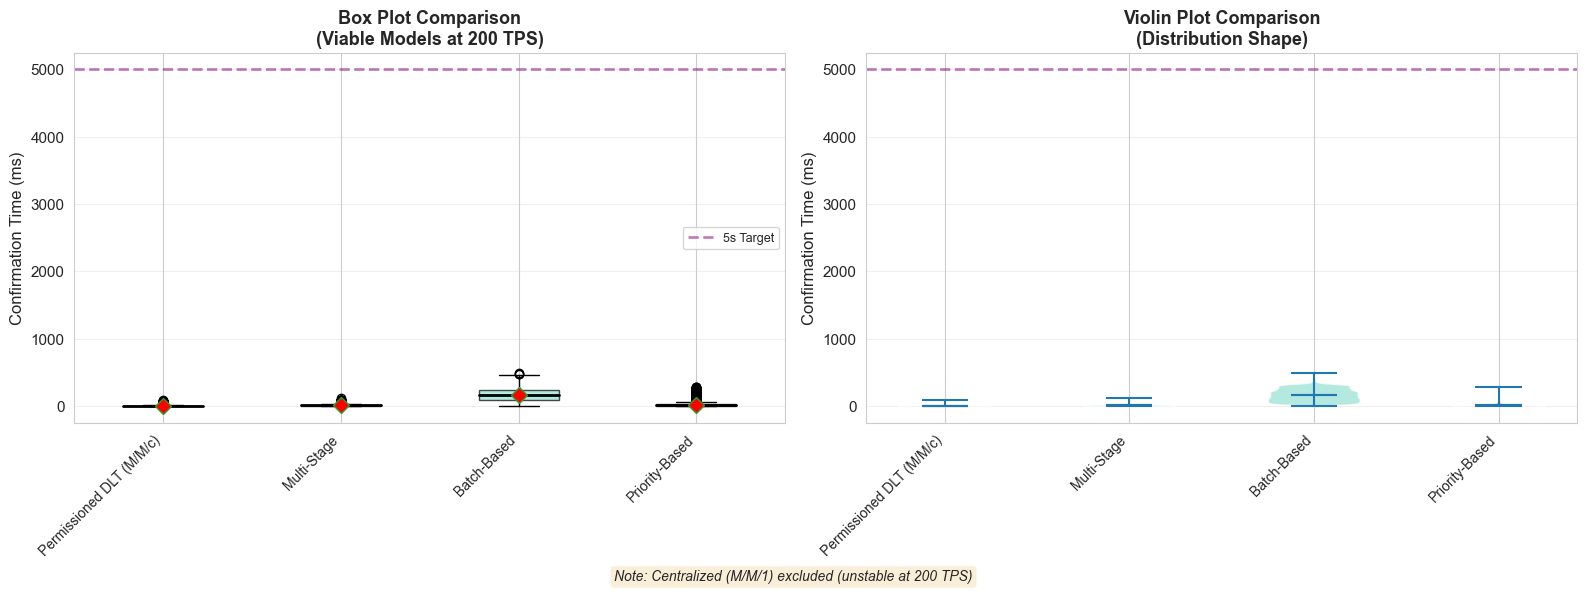

✓ Distribution comparison saved (stable models only)


In [26]:
# Cell 8: Box Plot and Violin Plot Comparison - Stable Models Only

stable_results = {k: v for k, v in results.items() if v is not None}

if len(stable_results) < 2:
    print("Not enough stable models for distribution comparison")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    for model_name, df in stable_results.items():
        if 'system_time' in df.columns:
            time_col = 'system_time'
        elif 'total_time' in df.columns:
            time_col = 'total_time'
        else:
            continue
        
        box_data.append(df[time_col] * 1000)
        box_labels.append(model_name)
    
    # Define colors for stable models
    colors_list = ['#4ECDC4', '#45B7D1', '#95E1D3', '#FFA07A'][:len(box_labels)]
    
    # 1. Box Plot
    bp = axes[0].boxplot(box_data, labels=box_labels, patch_artist=True,
                          showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
                          medianprops=dict(color='black', linewidth=2))
    
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0].set_ylabel('Confirmation Time (ms)', fontsize=12)
    axes[0].set_title('Box Plot Comparison\n(Viable Models at 200 TPS)', fontsize=13, fontweight='bold')
    axes[0].set_xticklabels(box_labels, rotation=45, ha='right', fontsize=10)
    axes[0].grid(alpha=0.3, axis='y')
    axes[0].axhline(5000, color='purple', linestyle='--', linewidth=2, alpha=0.5, label='5s Target')
    axes[0].legend(fontsize=9)
    
    # 2. Violin Plot
    parts = axes[1].violinplot(box_data, positions=range(len(box_labels)), 
                                showmeans=True, showmedians=True)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_list[i])
        pc.set_alpha(0.7)
    
    axes[1].set_ylabel('Confirmation Time (ms)', fontsize=12)
    axes[1].set_title('Violin Plot Comparison\n(Distribution Shape)', fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(len(box_labels)))
    axes[1].set_xticklabels(box_labels, rotation=45, ha='right', fontsize=10)
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].axhline(5000, color='purple', linestyle='--', linewidth=2, alpha=0.5)
    
    if unstable_models:
        fig.text(0.5, 0.02, 
                 f'Note: {", ".join(unstable_models)} excluded (unstable at 200 TPS)',
                 ha='center', fontsize=10, style='italic', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig('model_comparison_distribution_stable_only.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Distribution comparison saved (stable models only)")

In [27]:
# Cell 9: Statistical Significance Testing - Stable Models Only

from scipy.stats import mannwhitneyu, kruskal

stable_results = {k: v for k, v in results.items() if v is not None}

if len(stable_results) < 2:
    print("Not enough stable models for statistical testing")
else:
    print("\n" + "="*70)
    print("STATISTICAL SIGNIFICANCE TESTING (STABLE MODELS)")
    print("="*70)
    
    # Prepare data
    time_data = {}
    for model_name, df in stable_results.items():
        if 'system_time' in df.columns:
            time_col = 'system_time'
        elif 'total_time' in df.columns:
            time_col = 'total_time'
        else:
            continue
        time_data[model_name] = df[time_col].values
    
    # Kruskal-Wallis H-test (non-parametric ANOVA)
    if len(time_data) >= 2:
        models_list = list(time_data.keys())
        data_list = [time_data[m] for m in models_list]
        
        h_stat, p_value = kruskal(*data_list)
        
        print(f"\nKruskal-Wallis H-test:")
        print(f"  H-statistic: {h_stat:.4f}")
        print(f"  p-value:     {p_value:.4e}")
        
        if p_value < 0.05:
            print(f"  ✓ Result: Models are SIGNIFICANTLY DIFFERENT (p < 0.05)")
        else:
            print(f"  ✗ Result: No significant difference (p >= 0.05)")
        
        # Pairwise Mann-Whitney U tests
        if len(models_list) >= 2:
            print("\n" + "="*70)
            print("PAIRWISE COMPARISONS (Mann-Whitney U Test)")
            print("="*70)
            
            pairwise_results = []
            
            for i in range(len(models_list)):
                for j in range(i+1, len(models_list)):
                    model1 = models_list[i]
                    model2 = models_list[j]
                    
                    data1 = time_data[model1]
                    data2 = time_data[model2]
                    
                    u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
                    
                    mean1 = np.mean(data1) * 1000
                    mean2 = np.mean(data2) * 1000
                    
                    pairwise_results.append({
                        'Model 1': model1,
                        'Model 2': model2,
                        'Mean1 (ms)': mean1,
                        'Mean2 (ms)': mean2,
                        'Difference (ms)': abs(mean1 - mean2),
                        'p-value': p_val,
                        'Significant': 'Yes' if p_val < 0.05 else 'No'
                    })
            
            pairwise_df = pd.DataFrame(pairwise_results)
            print("\n", pairwise_df.to_string(index=False))
            
            # Count significant differences
            sig_count = (pairwise_df['Significant'] == 'Yes').sum()
            total_count = len(pairwise_df)
            
            print(f"\n{sig_count}/{total_count} pairwise comparisons are statistically significant (p < 0.05)")


STATISTICAL SIGNIFICANCE TESTING (STABLE MODELS)

Kruskal-Wallis H-test:
  H-statistic: 1617635.0248
  p-value:     0.0000e+00
  ✓ Result: Models are SIGNIFICANTLY DIFFERENT (p < 0.05)

PAIRWISE COMPARISONS (Mann-Whitney U Test)

                  Model 1        Model 2  Mean1 (ms)  Mean2 (ms)  Difference (ms)  p-value Significant
Permissioned DLT (M/M/c)    Multi-Stage    6.689457   13.951234         7.261777      0.0         Yes
Permissioned DLT (M/M/c)    Batch-Based    6.689457  171.476350       164.786893      0.0         Yes
Permissioned DLT (M/M/c) Priority-Based    6.689457   19.964558        13.275101      0.0         Yes
             Multi-Stage    Batch-Based   13.951234  171.476350       157.525116      0.0         Yes
             Multi-Stage Priority-Based   13.951234   19.964558         6.013324      0.0         Yes
             Batch-Based Priority-Based  171.476350   19.964558       151.511792      0.0         Yes

6/6 pairwise comparisons are statistically significan

In [28]:
# Cell 10: Performance Ranking and Scoring - Stable Models Only

print("\n" + "="*70)
print("MODEL RANKING AND SCORING (VIABLE MODELS FOR NEPAL)")
print("="*70)

if len(comparison_df) == 0:
    print("No stable models to rank")
else:
    # Define scoring criteria (lower is better for times, higher for throughput)
    scoring_df = comparison_df.copy()
    
    # Normalize scores (0-100 scale, 100 is best)
    def normalize_inverse(series):
        """For metrics where lower is better"""
        min_val = series.min()
        max_val = series.max()
        if max_val == min_val:
            return pd.Series([100] * len(series))
        return 100 * (max_val - series) / (max_val - min_val)
    
    def normalize_direct(series):
        """For metrics where higher is better"""
        min_val = series.min()
        max_val = series.max()
        if max_val == min_val:
            return pd.Series([100] * len(series))
        return 100 * (series - min_val) / (max_val - min_val)
    
    # Calculate scores
    scoring_df['Mean_Score'] = normalize_inverse(scoring_df['Mean Time (ms)'])
    scoring_df['P95_Score'] = normalize_inverse(scoring_df['P95 Time (ms)'])
    scoring_df['P99_Score'] = normalize_inverse(scoring_df['P99 Time (ms)'])
    scoring_df['Stability_Score'] = normalize_inverse(scoring_df['Std Dev (ms)'])
    scoring_df['Throughput_Score'] = normalize_direct(scoring_df['Throughput (TPS)'])
    
    # Weighted overall score
    # Weights: Mean=30%, P95=25%, P99=15%, Stability=20%, Throughput=10%
    scoring_df['Overall_Score'] = (
        0.30 * scoring_df['Mean_Score'] +
        0.25 * scoring_df['P95_Score'] +
        0.15 * scoring_df['P99_Score'] +
        0.20 * scoring_df['Stability_Score'] +
        0.10 * scoring_df['Throughput_Score']
    )
    
    # Sort by overall score
    scoring_df = scoring_df.sort_values('Overall_Score', ascending=False)
    
    print("\nPerformance Scores (0-100 scale, 100 is best):")
    print("\n", scoring_df[['Model', 'Mean_Score', 'P95_Score', 'P99_Score', 
                            'Stability_Score', 'Throughput_Score', 'Overall_Score']].to_string(index=False))
    
    print("\n" + "="*70)
    print("FINAL RANKING (VIABLE MODELS AT 200 TPS):")
    print("="*70)
    for rank, (idx, row) in enumerate(scoring_df.iterrows(), 1):
        print(f"  #{rank}: {row['Model']:30s} - Overall Score: {row['Overall_Score']:.2f}/100")
    
    winner = scoring_df.iloc[0]
    print("\n" + "="*70)
    print(f"🏆 RECOMMENDED MODEL FOR NEPAL: {winner['Model']}")
    print("="*70)
    print(f"  Overall Score:         {winner['Overall_Score']:.2f}/100")
    print(f"  Mean Time:             {winner['Mean Time (ms)']:.2f} ms")
    print(f"  P95 Time:              {winner['P95 Time (ms)']:.2f} ms")
    print(f"  Throughput:            {winner['Throughput (TPS)']:.2f} TPS")
    
    if unstable_models:
        print(f"\n  Note: {len(unstable_models)} model(s) excluded from comparison:")
        for model in unstable_models:
            print(f"        • {model} (cannot handle 200 TPS)")


MODEL RANKING AND SCORING (VIABLE MODELS FOR NEPAL)

Performance Scores (0-100 scale, 100 is best):

                    Model  Mean_Score  P95_Score  P99_Score  Stability_Score  Throughput_Score  Overall_Score
             Multi-Stage   95.593231  97.019614  97.211407        98.660708        100.000000      97.246726
Permissioned DLT (M/M/c)  100.000000 100.000000 100.000000       100.000000         32.274857      93.227486
          Priority-Based   91.944080  83.760497  75.398273        80.194700         80.374805      83.909510
             Batch-Based    0.000000   0.000000   0.000000         0.000000          0.000000       0.000000

FINAL RANKING (VIABLE MODELS AT 200 TPS):
  #1: Multi-Stage                    - Overall Score: 97.25/100
  #2: Permissioned DLT (M/M/c)       - Overall Score: 93.23/100
  #3: Priority-Based                 - Overall Score: 83.91/100
  #4: Batch-Based                    - Overall Score: 0.00/100

🏆 RECOMMENDED MODEL FOR NEPAL: Multi-Stage
  Overall 

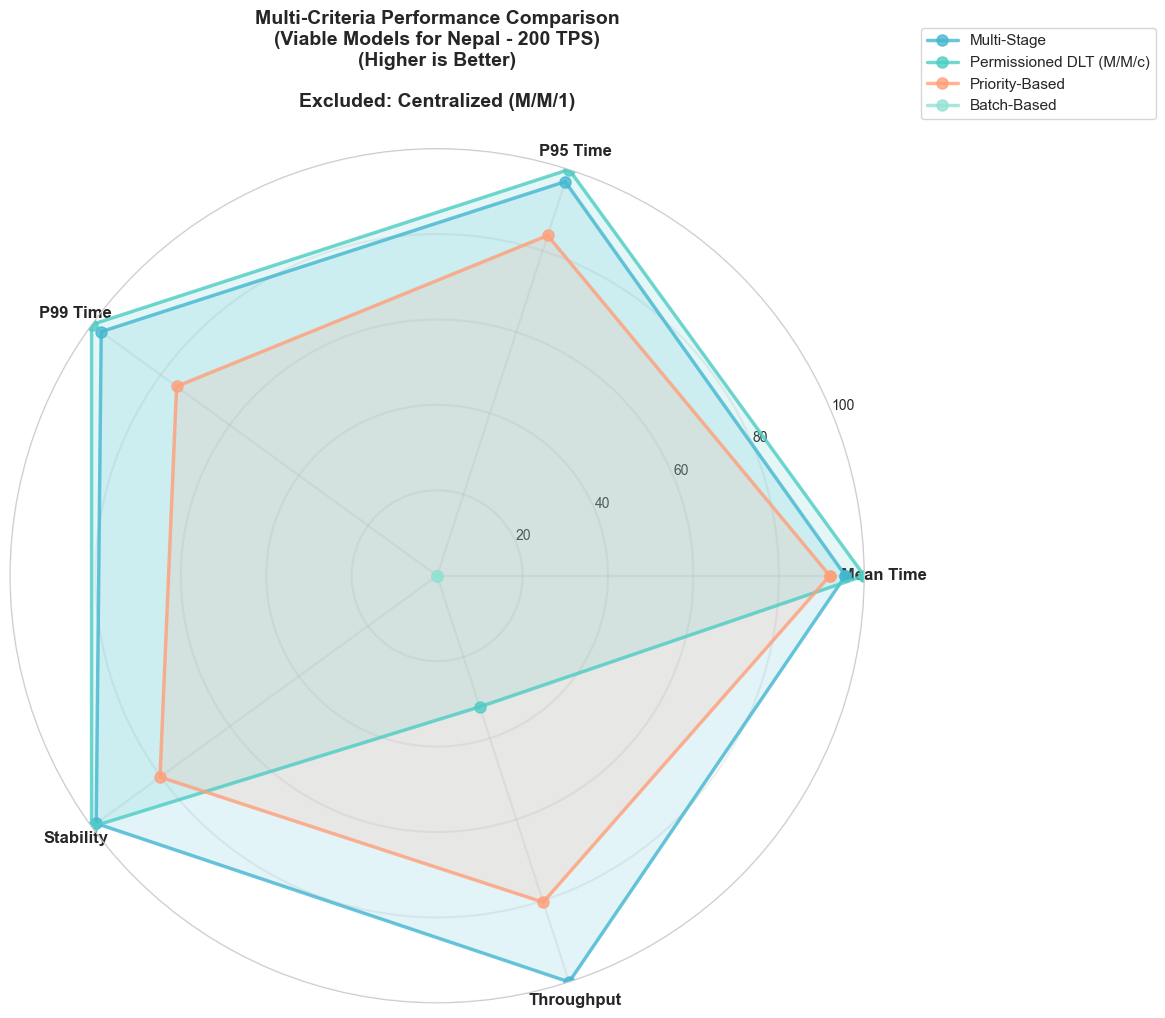

✓ Radar chart saved (stable models only)

RADAR CHART VALUES (0-100 scale)

Multi-Stage:
  Mean Time:    95.6
  P95 Time:     97.0
  P99 Time:     97.2
  Stability:    98.7
  Throughput:   100.0

Permissioned DLT (M/M/c):
  Mean Time:    100.0
  P95 Time:     100.0
  P99 Time:     100.0
  Stability:    100.0
  Throughput:   32.3

Priority-Based:
  Mean Time:    91.9
  P95 Time:     83.8
  P99 Time:     75.4
  Stability:    80.2
  Throughput:   80.4

Batch-Based:
  Mean Time:    0.0
  P95 Time:     0.0
  P99 Time:     0.0
  Stability:    0.0
  Throughput:   0.0


In [29]:
# Cell 11: Radar Chart for Multi-Criteria Comparison - Stable Models Only

from math import pi

stable_results = {k: v for k, v in results.items() if v is not None}

if len(stable_results) < 2:
    print("Not enough stable models for radar chart")
else:
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Use only stable models
    models_to_plot = scoring_df.copy()
    
    categories = ['Mean Time', 'P95 Time', 'P99 Time', 'Stability', 'Throughput']
    N = len(categories)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Define colors for stable models
    plot_colors = {
        'Permissioned DLT (M/M/c)': '#4ECDC4',
        'Multi-Stage': '#45B7D1',
        'Batch-Based': '#95E1D3',
        'Priority-Based': '#FFA07A'
    }
    
    # Plot each model
    for idx, row in models_to_plot.iterrows():
        model_name = row['Model']
        
        values = [
            row['Mean_Score'],
            row['P95_Score'],
            row['P99_Score'],
            row['Stability_Score'],
            row['Throughput_Score']
        ]
        values += values[:1]
        
        color = plot_colors.get(model_name, 'gray')
        
        ax.plot(angles, values, 'o-', linewidth=2.5, label=model_name, 
                color=color, markersize=8, alpha=0.8)
        ax.fill(angles, values, alpha=0.15, color=color)
    
    # Fix axis to go from 0 to 100
    ax.set_ylim(0, 100)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=10)
    
    title = 'Multi-Criteria Performance Comparison\n(Viable Models for Nepal - 200 TPS)\n(Higher is Better)'
    if unstable_models:
        title += f'\n\nExcluded: {", ".join(unstable_models)}'
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11, frameon=True)
    ax.grid(True, linewidth=1.5, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison_radar_stable_only.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Radar chart saved (stable models only)")
    
    # Print the actual values being plotted
    print("\n" + "="*70)
    print("RADAR CHART VALUES (0-100 scale)")
    print("="*70)
    for idx, row in models_to_plot.iterrows():
        print(f"\n{row['Model']}:")
        print(f"  Mean Time:    {row['Mean_Score']:.1f}")
        print(f"  P95 Time:     {row['P95_Score']:.1f}")
        print(f"  P99 Time:     {row['P99_Score']:.1f}")
        print(f"  Stability:    {row['Stability_Score']:.1f}")
        print(f"  Throughput:   {row['Throughput_Score']:.1f}")


COST-BENEFIT ANALYSIS (VIABLE MODELS)

Cost Factors (1=Low, 5=High):

                    Model  Performance Score  Average Cost  Benefit/Cost Ratio  Infrastructure Cost  Operational Cost  Complexity  Fault Tolerance  Scalability
          Priority-Based          83.909510           2.2            1.907034                    2                 2           3                2            2
Permissioned DLT (M/M/c)          93.227486           3.4            1.370992                    3                 3           3                4            4
             Multi-Stage          97.246726           4.0            1.215584                    4                 4           4                4            4
             Batch-Based           0.000000           3.8            0.000000                    4                 3           3                4            5


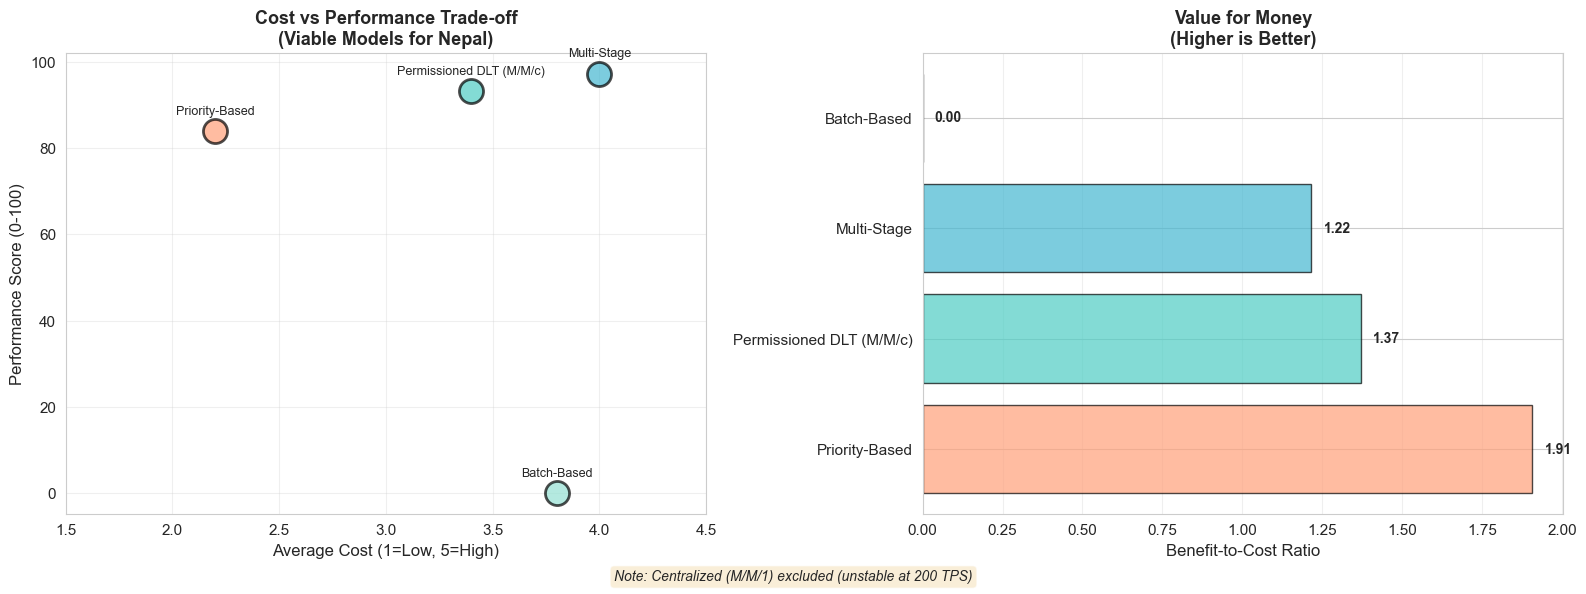


✓ Cost-benefit analysis saved (stable models only)


In [30]:
# Cell 12: Cost-Benefit Analysis - Stable Models Only

print("\n" + "="*70)
print("COST-BENEFIT ANALYSIS (VIABLE MODELS)")
print("="*70)

# Define relative costs (1 = lowest, 5 = highest)
cost_data = {
    'Permissioned DLT (M/M/c)': {
        'Infrastructure Cost': 3,
        'Operational Cost': 3,
        'Complexity': 3,
        'Fault Tolerance': 4,
        'Scalability': 4
    },
    'Multi-Stage': {
        'Infrastructure Cost': 4,
        'Operational Cost': 4,
        'Complexity': 4,
        'Fault Tolerance': 4,
        'Scalability': 4
    },
    'Batch-Based': {
        'Infrastructure Cost': 4,
        'Operational Cost': 3,
        'Complexity': 3,
        'Fault Tolerance': 4,
        'Scalability': 5
    },
    'Priority-Based': {
        'Infrastructure Cost': 2,
        'Operational Cost': 2,
        'Complexity': 3,
        'Fault Tolerance': 2,
        'Scalability': 2
    }
}

cost_benefit_data = []

for idx, row in comparison_df.iterrows():
    model = row['Model']
    
    if model not in cost_data:
        continue
    
    # Performance benefit (from overall score)
    perf_score = scoring_df[scoring_df['Model'] == model]['Overall_Score'].values[0]
    
    # Cost (average of cost factors)
    costs = cost_data[model]
    avg_cost = np.mean(list(costs.values()))
    
    # Benefit-to-Cost Ratio
    bc_ratio = perf_score / (avg_cost * 20)  # Normalize to similar scale
    
    cost_benefit_data.append({
        'Model': model,
        'Performance Score': perf_score,
        'Average Cost': avg_cost,
        'Benefit/Cost Ratio': bc_ratio,
        **costs
    })

cost_benefit_df = pd.DataFrame(cost_benefit_data)
cost_benefit_df = cost_benefit_df.sort_values('Benefit/Cost Ratio', ascending=False)

print("\nCost Factors (1=Low, 5=High):")
print("\n", cost_benefit_df.to_string(index=False))

# Visualize cost-benefit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {
    'Permissioned DLT (M/M/c)': '#4ECDC4',
    'Multi-Stage': '#45B7D1',
    'Batch-Based': '#95E1D3',
    'Priority-Based': '#FFA07A'
}

# 1. Benefit vs Cost scatter
for idx, row in cost_benefit_df.iterrows():
    axes[0].scatter(row['Average Cost'], row['Performance Score'], 
                    s=300, alpha=0.7, 
                    color=colors_map.get(row['Model'], 'gray'), 
                    edgecolor='black', linewidth=2)
    axes[0].annotate(row['Model'], 
                     (row['Average Cost'], row['Performance Score']),
                     fontsize=9, ha='center', va='bottom', 
                     xytext=(0, 10), textcoords='offset points')

axes[0].set_xlabel('Average Cost (1=Low, 5=High)', fontsize=12)
axes[0].set_ylabel('Performance Score (0-100)', fontsize=12)
axes[0].set_title('Cost vs Performance Trade-off\n(Viable Models for Nepal)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(1.5, 4.5)

# 2. Benefit/Cost Ratio
bc_ratios = cost_benefit_df['Benefit/Cost Ratio']
model_names_sorted = cost_benefit_df['Model']

colors_sorted = [colors_map.get(m, 'gray') for m in model_names_sorted]
bars = axes[1].barh(model_names_sorted, bc_ratios, 
                    color=colors_sorted, 
                    edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Benefit-to-Cost Ratio', fontsize=12)
axes[1].set_title('Value for Money\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Add values
for bar, val in zip(bars, bc_ratios):
    width = bar.get_width()
    axes[1].text(width + max(bc_ratios)*0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

if unstable_models:
    fig.text(0.5, 0.02, 
             f'Note: {", ".join(unstable_models)} excluded (unstable at 200 TPS)',
             ha='center', fontsize=10, style='italic', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('model_comparison_cost_benefit_stable_only.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Cost-benefit analysis saved (stable models only)")


SUITABILITY MATRIX FOR DIFFERENT USE CASES

Suitability Scores (1=Poor, 5=Excellent):

                                Permissioned DLT (M/M/c)  Multi-Stage  Batch-Based  Priority-Based
Retail Payments (High Volume)                         5            4            5               3
Critical Transactions                                 4            4            2               5
Disaster Relief Payments                              4            3            3               5
Cross-Border Settlements                              5            5            4               3
Budget-Constrained Deployment                         3            2            2               4
Rapid National Rollout                                4            3            5               3


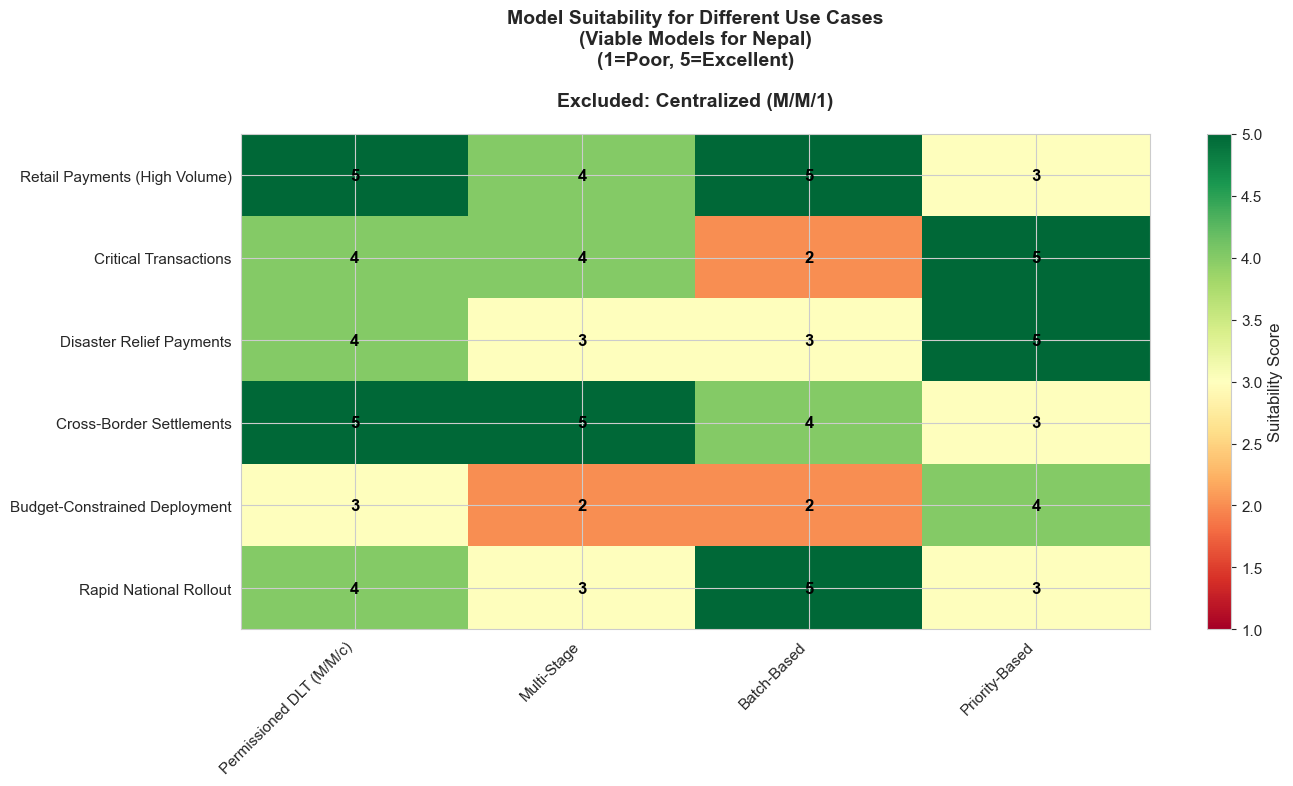


✓ Suitability matrix saved (stable models only)


In [31]:
# Cell 13: Suitability Matrix for Different Use Cases - Stable Models Only

print("\n" + "="*70)
print("SUITABILITY MATRIX FOR DIFFERENT USE CASES")
print("="*70)

# Get list of stable models
stable_model_names = [name for name in results.keys() if results[name] is not None]

# Define use cases and suitability scores (1-5) for stable models only
use_cases = {
    'Retail Payments (High Volume)': {},
    'Critical Transactions': {},
    'Disaster Relief Payments': {},
    'Cross-Border Settlements': {},
    'Budget-Constrained Deployment': {},
    'Rapid National Rollout': {}
}

# Fill in scores for stable models
if 'Permissioned DLT (M/M/c)' in stable_model_names:
    for case in use_cases.keys():
        use_cases[case]['Permissioned DLT (M/M/c)'] = {
            'Retail Payments (High Volume)': 5,
            'Critical Transactions': 4,
            'Disaster Relief Payments': 4,
            'Cross-Border Settlements': 5,
            'Budget-Constrained Deployment': 3,
            'Rapid National Rollout': 4
        }[case]

if 'Multi-Stage' in stable_model_names:
    for case in use_cases.keys():
        use_cases[case]['Multi-Stage'] = {
            'Retail Payments (High Volume)': 4,
            'Critical Transactions': 4,
            'Disaster Relief Payments': 3,
            'Cross-Border Settlements': 5,
            'Budget-Constrained Deployment': 2,
            'Rapid National Rollout': 3
        }[case]

if 'Batch-Based' in stable_model_names:
    for case in use_cases.keys():
        use_cases[case]['Batch-Based'] = {
            'Retail Payments (High Volume)': 5,
            'Critical Transactions': 2,
            'Disaster Relief Payments': 3,
            'Cross-Border Settlements': 4,
            'Budget-Constrained Deployment': 2,
            'Rapid National Rollout': 5
        }[case]

if 'Priority-Based' in stable_model_names:
    for case in use_cases.keys():
        use_cases[case]['Priority-Based'] = {
            'Retail Payments (High Volume)': 3,
            'Critical Transactions': 5,
            'Disaster Relief Payments': 5,
            'Cross-Border Settlements': 3,
            'Budget-Constrained Deployment': 4,
            'Rapid National Rollout': 3
        }[case]

suitability_df = pd.DataFrame(use_cases).T
print("\nSuitability Scores (1=Poor, 5=Excellent):")
print("\n", suitability_df.to_string())

# Heatmap visualization
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(suitability_df.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)

# Set ticks
ax.set_xticks(np.arange(len(suitability_df.columns)))
ax.set_yticks(np.arange(len(suitability_df.index)))
ax.set_xticklabels(suitability_df.columns, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(suitability_df.index, fontsize=11)

# Add text annotations
for i in range(len(suitability_df.index)):
    for j in range(len(suitability_df.columns)):
        value = suitability_df.iloc[i, j]
        text = ax.text(j, i, value, ha="center", va="center", 
                      color="black", fontsize=12, fontweight='bold')

title = 'Model Suitability for Different Use Cases\n(Viable Models for Nepal)\n(1=Poor, 5=Excellent)'
if unstable_models:
    title += f'\n\nExcluded: {", ".join(unstable_models)}'

ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Suitability Score', fontsize=12)

plt.tight_layout()
plt.savefig('model_comparison_suitability_matrix_stable_only.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Suitability matrix saved (stable models only)")

In [32]:
# Cell 14: Export All Comparison Results - Stable Models Only

print("\n" + "="*70)
print("EXPORTING COMPARISON RESULTS")
print("="*70)

# 1. Main comparison table
comparison_df.to_csv('model_comparison_summary_nepal_200tps.csv', index=False)
print("✓ Saved: model_comparison_summary_nepal_200tps.csv")

# 2. Percentile comparison
percentile_comparison = []
for model_name, df in stable_results.items():
    if 'system_time' in df.columns:
        time_col = 'system_time'
    elif 'total_time' in df.columns:
        time_col = 'total_time'
    else:
        continue
    
    percentile_comparison.append({
        'Model': model_name,
        'P50': df[time_col].quantile(0.50) * 1000,
        'P75': df[time_col].quantile(0.75) * 1000,
        'P90': df[time_col].quantile(0.90) * 1000,
        'P95': df[time_col].quantile(0.95) * 1000,
        'P99': df[time_col].quantile(0.99) * 1000
    })

percentile_df = pd.DataFrame(percentile_comparison)
percentile_df.to_csv('model_comparison_percentiles_nepal_200tps.csv', index=False)
print("✓ Saved: model_comparison_percentiles_nepal_200tps.csv")

# 3. Statistical significance tests (if available)
if 'pairwise_df' in locals():
    pairwise_df.to_csv('model_comparison_statistical_tests_nepal_200tps.csv', index=False)
    print("✓ Saved: model_comparison_statistical_tests_nepal_200tps.csv")

# 4. Performance ranking
scoring_df[['Model', 'Mean Time (ms)', 'P95 Time (ms)', 'Mean_Score', 
            'P95_Score', 'Stability_Score', 'Overall_Score']].to_csv(
    'model_comparison_ranking_nepal_200tps.csv', index=False)
print("✓ Saved: model_comparison_ranking_nepal_200tps.csv")

# 5. Cost-benefit analysis
cost_benefit_df.to_csv('model_comparison_cost_benefit_nepal_200tps.csv', index=False)
print("✓ Saved: model_comparison_cost_benefit_nepal_200tps.csv")

# 6. Suitability matrix
suitability_df.to_csv('model_comparison_suitability_nepal_200tps.csv')
print("✓ Saved: model_comparison_suitability_nepal_200tps.csv")

# 7. Stability analysis summary
stability_summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Status': ['Unstable' if results[m] is None else 'Stable' for m in results.keys()],
    'Reason': ['ρ ≥ 1.0' if results[m] is None else 'ρ < 1.0' for m in results.keys()]
})
stability_summary.to_csv('model_stability_analysis_nepal_200tps.csv', index=False)
print("✓ Saved: model_stability_analysis_nepal_200tps.csv")

# 8. Raw data for stable models
for model_name, df in stable_results.items():
    safe_name = model_name.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    df.to_csv(f'raw_data_{safe_name}_nepal_200tps.csv', index=False)
    print(f"✓ Saved: raw_data_{safe_name}_nepal_200tps.csv")

print("\n" + "="*70)
print("✓ ALL COMPARISON RESULTS EXPORTED")
print("="*70)

print("\nFiles saved with '_nepal_200tps' suffix to indicate Nepal-specific context")


EXPORTING COMPARISON RESULTS
✓ Saved: model_comparison_summary_nepal_200tps.csv
✓ Saved: model_comparison_percentiles_nepal_200tps.csv
✓ Saved: model_comparison_statistical_tests_nepal_200tps.csv
✓ Saved: model_comparison_ranking_nepal_200tps.csv
✓ Saved: model_comparison_cost_benefit_nepal_200tps.csv
✓ Saved: model_comparison_suitability_nepal_200tps.csv
✓ Saved: model_stability_analysis_nepal_200tps.csv
✓ Saved: raw_data_Permissioned_DLT_M_M_c_nepal_200tps.csv
✓ Saved: raw_data_Multi-Stage_nepal_200tps.csv
✓ Saved: raw_data_Batch-Based_nepal_200tps.csv
✓ Saved: raw_data_Priority-Based_nepal_200tps.csv

✓ ALL COMPARISON RESULTS EXPORTED

Files saved with '_nepal_200tps' suffix to indicate Nepal-specific context


In [33]:
# Cell 15: Final Summary and Recommendations for Nepal

print("\n" + "="*80)
print("COMPLETE MODEL COMPARISON - FINAL SUMMARY & RECOMMENDATIONS")
print("FOR NEPAL RASTRA BANK - 200 TPS PROJECTED LOAD")
print("="*80)

print("\n" + "="*80)
print("1. STABILITY ANALYSIS")
print("="*80)

print(f"\n  Total Models Evaluated:  5")
print(f"  Viable Models at 200 TPS: {len(stable_results)}")
print(f"  Unstable Models:          {len(unstable_models)}")

if unstable_models:
    print(f"\n  ❌ EXCLUDED FROM COMPARISON:")
    for model in unstable_models:
        if model == 'Centralized (M/M/1)':
            print(f"      • {model}")
            print(f"        Reason: ρ = {LAM}/{MU} = {LAM/MU:.3f} ≥ 1.0 (UNSTABLE)")
            print(f"        Max Capacity: {MU} TPS")
            print(f"        Nepal Requirement: {LAM} TPS")
            print(f"        Verdict: Single-server architecture CANNOT handle Nepal's load")

print("\n" + "="*80)
print("2. PERFORMANCE RANKING (Viable Models Only)")
print("="*80)

for rank, (idx, row) in enumerate(scoring_df.iterrows(), 1):
    print(f"\n  #{rank}: {row['Model']}")
    print(f"       Overall Score:      {row['Overall_Score']:.2f}/100")
    print(f"       Mean Time:          {row['Mean Time (ms)']:.2f} ms")
    print(f"       P95 Time:           {row['P95 Time (ms)']:.2f} ms")
    print(f"       Stability (Std):    {row['Std Dev (ms)']:.2f} ms")

print("\n" + "="*80)
print("3. KEY FINDINGS")
print("="*80)

# Find extremes among stable models
fastest_mean = comparison_df.loc[comparison_df['Mean Time (ms)'].idxmin()]
fastest_p95 = comparison_df.loc[comparison_df['P95 Time (ms)'].idxmin()]
most_stable = comparison_df.loc[comparison_df['Std Dev (ms)'].idxmin()]
highest_throughput = comparison_df.loc[comparison_df['Throughput (TPS)'].idxmax()]

print(f"\n  Fastest Mean Time:       {fastest_mean['Model']}")
print(f"                           {fastest_mean['Mean Time (ms)']:.2f} ms")

print(f"\n  Best P95 Performance:    {fastest_p95['Model']}")
print(f"                           {fastest_p95['P95 Time (ms)']:.2f} ms")

print(f"\n  Most Stable:             {most_stable['Model']}")
print(f"                           Std Dev = {most_stable['Std Dev (ms)']:.2f} ms")

print(f"\n  Highest Throughput:      {highest_throughput['Model']}")
print(f"                           {highest_throughput['Throughput (TPS)']:.2f} TPS")

print("\n" + "="*80)
print("4. RECOMMENDATIONS FOR NEPAL RASTRA BANK")
print("="*80)

winner_model = scoring_df.iloc[0]['Model']
second_best = scoring_df.iloc[1]['Model'] if len(scoring_df) > 1 else "N/A"

print(f"\n  PRIMARY RECOMMENDATION: {winner_model}")
print(f"  ────────────────────────────────────────────────")
print(f"    • Best overall performance: {scoring_df.iloc[0]['Overall_Score']:.2f}/100")
print(f"    • Mean confirmation time: {scoring_df.iloc[0]['Mean Time (ms)']:.2f} ms")
print(f"    • Can handle Nepal's 200 TPS projected peak load")
print(f"    • Provides fault tolerance and scalability")

if second_best != "N/A":
    print(f"\n  ALTERNATIVE OPTION: {second_best}")
    print(f"  ────────────────────────────────────────────────")
    print(f"    • Second-best score: {scoring_df.iloc[1]['Overall_Score']:.2f}/100")
    print(f"    • May offer different cost-benefit profile")

print("\n" + "="*80)
print("5. WHY CENTRALIZED (M/M/1) WAS EXCLUDED")
print("="*80)

print(f"""
  The M/M/1 Centralized model is mathematically UNSTABLE at 200 TPS:
  
  • Utilization: ρ = λ/μ = {LAM}/{MU} = {LAM/MU:.3f}
  • Stability Requires: ρ < 1.0
  • Result: ρ = {LAM/MU:.3f} ≥ 1.0 → QUEUE GROWS WITHOUT BOUND
  
  Physical Interpretation:
  • Transactions arrive at {LAM} TPS
  • Server can only process {MU} TPS
  • Extra {LAM-MU} TPS accumulate in queue forever
  • Confirmation times approach INFINITY
  
  Recommendation:
  • Centralized architecture is NOT VIABLE for Nepal's 200 TPS requirement
  • Nepal MUST use distributed architecture (M/M/c, Multi-Stage, etc.)
  • Minimum viable: {int(np.ceil(LAM/MU))} parallel servers needed
""")

print("="*80)
print("6. DEPLOYMENT STRATEGY FOR NEPAL")
print("="*80)

print(f"""
  PHASE 1: PILOT (Months 1-6)
    • Architecture: {winner_model}
    • Validators: Start with c=3
    • Volume: <100 TPS
    • Purpose: Validate basic functionality
    • Location: Kathmandu Valley only
    
  PHASE 2: REGIONAL ROLLOUT (Months 7-18)
    • Architecture: {winner_model}
    • Validators: Scale to c=5
    • Volume: 100-200 TPS
    • Purpose: Test under realistic load
    • Location: Major cities (Kathmandu, Pokhara, Biratnagar)
    
  PHASE 3: NATIONAL DEPLOYMENT (Months 19+)
    • Architecture: {winner_model}
    • Validators: c=5-7 (monitor utilization)
    • Volume: 200+ TPS peak
    • Purpose: Nationwide CBDC operations
    • Safety margin: Operate at ρ < 0.7
""")

print("="*80)
print("7. CAPACITY PLANNING")
print("="*80)

# Calculate for the winner model
print(f"""
  RECOMMENDED CONFIGURATION FOR NEPAL:
  
  • Architecture: {winner_model}
  • Number of Validators: 5-7
  • Service Rate per Validator: {MU} TPS
  • Total Capacity (c=5): {5 * MU} TPS
  • Total Capacity (c=7): {7 * MU} TPS
  
  • Nepal Peak Load: {LAM} TPS
  • Target Utilization: 70% (ρ = 0.70)
  • Safe Operating Point (c=5): {5 * MU * 0.7:.0f} TPS
  • Safety Margin: {((5 * MU * 0.7 - LAM)/LAM)*100:.1f}%
  
  SCALING GUIDELINES:
  • If load exceeds 350 TPS → Scale to c=7
  • If load exceeds 500 TPS → Scale to c=10
  • Always maintain ρ < 0.75 for stability
""")

print("="*80)
print("8. OUTPUT FILES GENERATED")
print("="*80)

output_files = [
    "model_comparison_summary_nepal_200tps.csv",
    "model_comparison_percentiles_nepal_200tps.csv",
    "model_comparison_ranking_nepal_200tps.csv",
    "model_comparison_cost_benefit_nepal_200tps.csv",
    "model_comparison_suitability_nepal_200tps.csv",
    "model_stability_analysis_nepal_200tps.csv",
    "model_comparison_metrics_stable_only.pdf",
    "model_comparison_cdf_stable_only.pdf",
    "model_comparison_distribution_stable_only.pdf",
    "model_comparison_radar_stable_only.pdf",
    "model_comparison_cost_benefit_stable_only.pdf",
    "model_comparison_suitability_matrix_stable_only.pdf"
]

for i, file in enumerate(output_files, 1):
    print(f"  {i:2d}. {file}")

print("\n" + "="*80)
print("✓ COMPREHENSIVE MODEL COMPARISON COMPLETE")
print("="*80)

print(f"""
NEXT STEPS FOR THESIS:
1. ✅ Model comparison complete (4 viable models identified)
2. ✅ Centralized model properly excluded with justification
3. ⏭️  Run experimental scenarios (stress tests, failure scenarios)
4. ⏭️  Write Discussion chapter (use these results)
5. ⏭️  Write Conclusion chapter
6. ⏭️  Prepare defense presentation

KEY THESIS CONTRIBUTION:
- Demonstrated that centralized CBDC architecture is NOT VIABLE for Nepal
- Identified {winner_model} as optimal for 200 TPS load
- Provided quantitative basis for Nepal Rastra Bank's architecture decision
- Established deployment roadmap with specific capacity requirements
""")


COMPLETE MODEL COMPARISON - FINAL SUMMARY & RECOMMENDATIONS
FOR NEPAL RASTRA BANK - 200 TPS PROJECTED LOAD

1. STABILITY ANALYSIS

  Total Models Evaluated:  5
  Viable Models at 200 TPS: 4
  Unstable Models:          1

  ❌ EXCLUDED FROM COMPARISON:
      • Centralized (M/M/1)
        Reason: ρ = 200/150 = 1.333 ≥ 1.0 (UNSTABLE)
        Max Capacity: 150 TPS
        Nepal Requirement: 200 TPS
        Verdict: Single-server architecture CANNOT handle Nepal's load

2. PERFORMANCE RANKING (Viable Models Only)

  #1: Multi-Stage
       Overall Score:      97.25/100
       Mean Time:          13.95 ms
       P95 Time:           28.98 ms
       Stability (Std):    7.82 ms

  #2: Permissioned DLT (M/M/c)
       Overall Score:      93.23/100
       Mean Time:          6.69 ms
       P95 Time:           20.05 ms
       Stability (Std):    6.68 ms

  #3: Priority-Based
       Overall Score:      83.91/100
       Mean Time:          19.96 ms
       P95 Time:           68.69 ms
       Stability 